In [ ]:
using LinearAlgebra, SparseArrays, Parameters, LinearMaps, Plots, Serialization
plotlyjs()   # Enables interactive rotation


Plots.PlotlyJSBackend()

In [2]:
# #1D Matrix operator utility functions.
# spI(n) = spdiagm(n,n, 0 => ones(n))
# ∂1d(n,dx) = spdiagm(n,n+1,0 => -ones(n), 1 => ones(n))/dx
# c(n) = spdiagm(n,n+1,0 => ones(n), 1 => ones(n))/2
# χ(n) = spdiagm(n,n+2, 1 => ones(n))


In [3]:
# A = spI(5)
# rank(∂1d(5,0.1))
# ∂1d(5,0.1)

In [263]:
# Define parameters
Base.@kwdef struct Params
    y_BC::String = "Neumann" # or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 20      # max staggered iterations
    savefile::String = "sol.jls" # file to save iterations
end

# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny
    λ,μ = p.λ,p.μ

    Q111 = zeros(Nx,Ny)
    P111 = zeros(Nx,Ny)
    Q112 = zeros(Nx,Ny)
    P112 = zeros(Nx,Ny)

    Q121 = zeros(Nx,Ny)
    P121 = zeros(Nx,Ny)
    Q122 = zeros(Nx,Ny)
    P122 = zeros(Nx,Ny)

    Q221 = zeros(Nx,Ny)
    P221 = zeros(Nx,Ny)
    Q222 = zeros(Nx,Ny)
    P222 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            # # pressure
            # pres = -(λ + 2μ/3)*(a1barx + a2bary)
            # # mask
            # if pres <= 0 
            #     m_p = 1.0
            # else    
            #     m_p = g(d, i, j, p)
            # end

            # # from linearisation
            # fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            # if fbar == 0.0 # strictly
            #     r1x = 1/6 - 1/(2^(3/2))
            #     r1y = -1/(2^(3/2))
            #     r2x = -1/(2^(3/2))
            #     r2y = 1/6 + 1/(2^(3/2))
            # else
            #     r1x = 1/6 - (a1barx - a2bary)/(2fbar)
            #     r1y = -(a1bary + a2barx)/(2fbar)
            #     r2x = -(a1bary + a2barx)/(2fbar)
            #     r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            # end

            # q1 = (a1barx + a2bary)/6 - 0.5*fbar
            # q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # # masks
            # m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            # m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            # for a1x
            Q111[i,j] = λ + 2*μ
            # for a1y
            #P111[i,j] = 
            # for a2x 
            #Q112[i,j] = 
            # for a2y
            P112[i,j] = λ

            #Q121[i,j] = 
            P121[i,j] = μ 
            Q122[i,j] = μ
            #P122[i,j] = 

            Q221[i,j] = λ
            #P221[i,j] = 
            #Q222[i,j] = 
            P222[i,j] = λ + 2*μ
        end
    end

    return Q111,P111,Q112, P112,
           Q121,P121,Q122,P122,
           Q221,P221,Q222,P222
end

# Build global matrix M and rhs b
function build_system(Q111,P111,Q112,P112,
                      Q121,P121,Q122,P122,
                      Q221,P221,Q222,P222,
                      p::Params,
                      a1_left, a1_right,
                      a2_left, a2_right)

    Nx,Ny = p.Nx,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized
    Ndof = 2*Ntot # for both a1 and a2

    λ, μ = p.λ, p.μ

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)

    # Dirichlet in x
    # for i = 1
    for j in 1:Ny
        k = lin(1,j,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        M[k1,k1]=1; b[k1]=a1_left[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_left[j]
    end
    # for i = Nx
    for j in 1:Ny
        k = lin(Nx,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2
        M[k1,k1]=1; b[k1]=a1_right[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_right[j]
    end
    
    # BC in y
    if p.y_BC=="Neumann" # using 1st order stencils
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = -1/Δy
            M[k1,lin(i,2,Nx)] = 1/Δy
            M[k2,k2] = -1/Δy
            M[k2,lin(i,2,Nx)+Ntot] = 1/Δy
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = 1/Δy
            M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            M[k2,k2] = 1/Δy
            M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
        end
    elseif p.y_BC == "traction_free"
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(-1/Δy)
            M[k1,lin(i,2,Nx)] = μ*(1/Δy)
            M[k1,lin(i+1,1,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,1,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,1,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,1,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(-1/Δy)
            M[k2,lin(i,2,Nx)+Ntot] = (λ+2*μ)*(1/Δy)
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # M[k1,k1] = 1/Δy
            # M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            # M[k2,k2] = 1/Δy
            # M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(1/Δy)
            M[k1,lin(i,Ny-1,Nx)] = μ*(-1/Δy)
            M[k1,lin(i+1,Ny,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,Ny,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,Ny,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,Ny,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(1/Δy)
            M[k2,lin(i,Ny-1,Nx)+Ntot] = (λ+2*μ)*(-1/Δy)

        end
     end
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            # sigma_11
            P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
            P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
            Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
            Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
            P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
            P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
            Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
            Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
            # sigma_12
            P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
            P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
            Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
            Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
            P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
            P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
            Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
            Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

            # midpoints in y
            # sigma_12
            P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
            P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
            Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
            Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
            P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
            P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
            Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
            Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
            # sigma_22
            P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
            P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
            Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
            Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
            P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
            P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
            Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
            Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

            # 2nd eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

        end
    end

    return M,b
end

build_system (generic function with 1 method)

In [295]:
p = Params(
    y_BC="Neumann",
    λ = 0.4,
    μ = 0.2,
    Nx = 20,
    Ny = 20,
    max_iter = 1
)

Params("Neumann", 1.0e-8, 0.4, 0.2, 1.0, 20, 0.05263157894736842, 1.0, 20, 0.05263157894736842, 11, 0.1, 1.0e-6, 1, "sol.jls")

In [296]:
a1 = zeros(p.Nx, p.Ny)
a2 = zeros(p.Nx, p.Ny)

a1_bar = copy(a1)
a2_bar = copy(a2)
d = copy(a2)

20×20 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

In [297]:
x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)
for j in 1:p.Ny
    for i in 1:p.Nx
        a1_bar[i,j] = 1e-1*sin(x[i])*cos(y[j])
        a2_bar[i,j] = 2*1e-1*cos(x[i])*sin(2*y[j])
    end
end

In [57]:
# heatmap(a2_bar,
# color = :coolwarm)   # Try :viridis, :inferno, :magma, :cividis)

In [298]:
Q111,P111,Q112,P112,
Q121,P121,Q122,P122,
Q221,P221,Q222,P222 =
    build_QP(d,a1_bar,a2_bar,p)

([0.8 0.8 … 0.8 0.8; 0.8 0.8 … 0.8 0.8; … ; 0.8 0.8 … 0.8 0.8; 0.8 0.8 … 0.8 0.8], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.4 0.4 … 0.4 0.4; 0.4 0.4 … 0.4 0.4; … ; 0.4 0.4 … 0.4 0.4; 0.4 0.4 … 0.4 0.4], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.2 0.2 … 0.2 0.2; 0.2 0.2 … 0.2 0.2; … ; 0.2 0.2 … 0.2 0.2; 0.2 0.2 … 0.2 0.2], [0.2 0.2 … 0.2 0.2; 0.2 0.2 … 0.2 0.2; … ; 0.2 0.2 … 0.2 0.2; 0.2 0.2 … 0.2 0.2], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.4 0.4 … 0.4 0.4; 0.4 0.4 … 0.4 0.4; … ; 0.4 0.4 … 0.4 0.4; 0.4 0.4 … 0.4 0.4], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.8 0.8 … 0.8 0.8; 0.8 0.8 … 0.8 0.8; … ; 0.8 0.8 … 0.8 0.8; 0.8 0.8 … 0.8 0.8])

In [299]:
a1_left  = 0.0*ones(p.Ny)
a1_right = 2*1e-1*ones(p.Ny)
a2_left  = 0.0*ones(p.Ny)
a2_right = 0*1e-1*ones(p.Ny)

20-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [300]:
M,b = build_system(
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222,
    p,
    a1_left,a1_right,
    a2_left,a2_right)

([1.0 0.0 … 0.0 0.0; 0.0 -19.0 … 0.0 0.0; … ; 0.0 0.0 … 19.0 0.0; 0.0 0.0 … 0.0 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [301]:
println("rank(M) = ", rank(M))
println("size(M) = ", size(M))
# println("det(M) = ", det(M))
# println("cond(M) = ", cond(M))

rank(M) = 800
size(M) = (800, 800)


In [302]:
M

800×800 Matrix{Float64}:
 1.0    0.0    0.0    0.0    0.0    0.0  …   0.0   0.0   0.0   0.0   0.0  0.0
 0.0  -19.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0  -19.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0  -19.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0  -19.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0  -19.0  …   0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0  …   0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0      0.0   0.0   0.0   0.0   0.0  0.0
 0.0    0.0    0.0    0.0    0.0    0.0

In [303]:
sol = M \ b

800-element Vector{Float64}:
 -5.800855252238815e-14
  0.010526315789413992
  0.021052631578887038
  0.031578947368346266
  0.04210526315783728
  0.0526315789473165
  0.06315789473676861
  0.07368421052628403
  0.08421052631575025
  0.09473684210521026
  0.10526315789466563
  0.11578947368412748
  0.12631578947364647
  ⋮
 -1.8526315789475887
 -1.9736842105265684
 -2.052631578947653
 -2.084210526316062
 -2.063157894737086
 -1.9842105263160137
 -1.842105263158071
 -1.6315789473685254
 -1.3473684210526566
 -0.9842105263157481
 -0.5368421052631166
  0.0

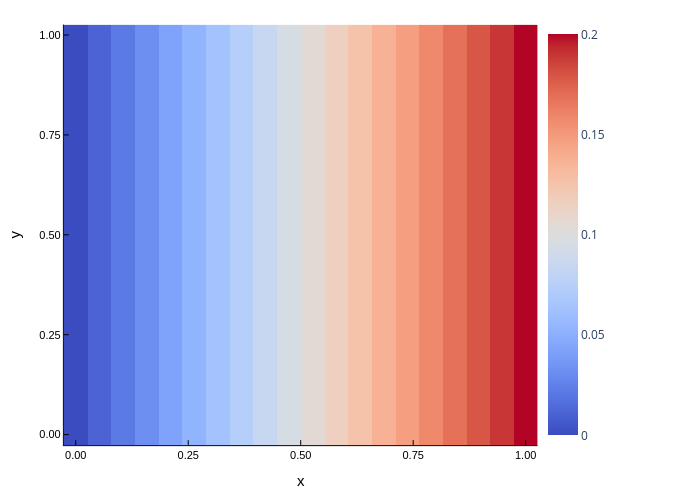

In [304]:
Ntot = p.Nx*p.Ny
a1sol = reshape(sol[1:Ntot], p.Nx, p.Ny)
heatmap(x,y,a1sol',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [305]:
a1sol

20×20 Matrix{Float64}:
 -5.80086e-14  -3.92122e-14  -3.65583e-13  …  -3.8325e-14  6.56784e-14
  0.0105263     0.0105263     0.0105263        0.0105263   0.0105263
  0.0210526     0.0210526     0.0210526        0.0210526   0.0210526
  0.0315789     0.0315789     0.0315789        0.0315789   0.0315789
  0.0421053     0.0421053     0.0421053        0.0421053   0.0421053
  0.0526316     0.0526316     0.0526316    …   0.0526316   0.0526316
  0.0631579     0.0631579     0.0631579        0.0631579   0.0631579
  0.0736842     0.0736842     0.0736842        0.0736842   0.0736842
  0.0842105     0.0842105     0.0842105        0.0842105   0.0842105
  0.0947368     0.0947368     0.0947368        0.0947368   0.0947368
  0.105263      0.105263      0.105263     …   0.105263    0.105263
  0.115789      0.115789      0.115789         0.115789    0.115789
  0.126316      0.126316      0.126316         0.126316    0.126316
  0.136842      0.136842      0.136842         0.136842    0.136842
  0.147368   

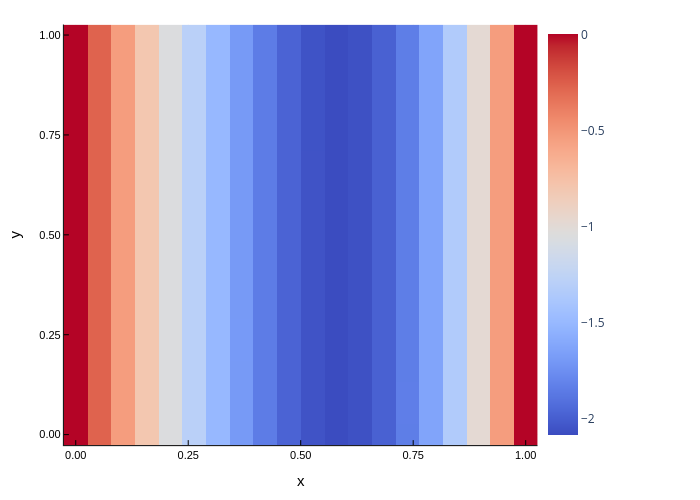

In [306]:
a2sol = reshape(sol[Ntot+1:2*Ntot], p.Nx, p.Ny)
heatmap(x,y, a2sol',
xlabel="x",
ylabel="y",
color=:coolwarm
)

In [254]:
# surface(x,y,a1sol',
# xlabel="x",
# ylabel="y",
# color=:coolwarm
# )

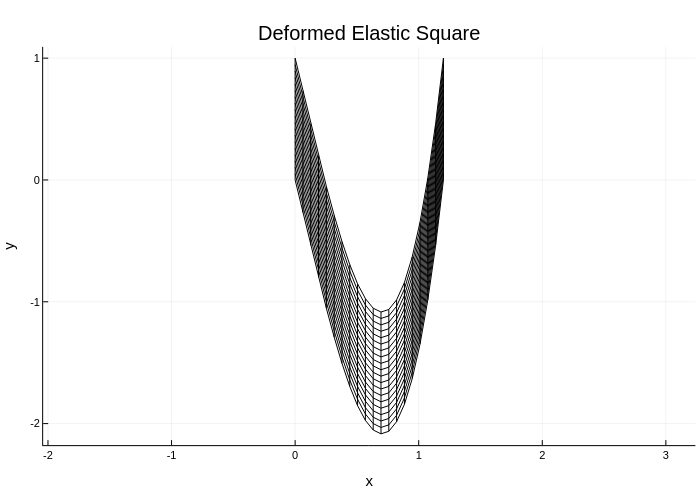

In [307]:
# Transpose for plotting consistency
a1p = a1sol'
a2p = a2sol'

# Build coordinate matrices
X = [xi for yi in y, xi in x]
Y = [yi for yi in y, xi in x]

# Deformed coordinates
Xd = X .+ a1p
Yd = Y .+ a2p

# Plot deformed grid
p1 = plot()

# horizontal lines
for i in 1:p.Ny
    plot!(Xd[i, :], Yd[i, :], color=:black, lw=1)
end

# vertical lines
for j in 1:p.Nx
    plot!(Xd[:, j], Yd[:, j], color=:black, lw=1)
end

plot!(
    aspect_ratio = 1,
    xlabel = "x",
    ylabel = "y",
    legend = false,
    title = "Deformed Elastic Square"
)

In [309]:
p.λ/(2*(p.λ+p.μ))

0.3333333333333333

In [308]:
maximum(abs.(a2sol))

2.0842105263160926